In [1]:
import os
import pandas as pd
import pickle
from matplotlib import pyplot as plt
import numpy as np
from ribbn_scripts.processing.get_offset import get_offset
from ribbn_scripts.processing.phase_estimate import multidist_multifreq_phase_estimation
from ribbn_scripts.processing.localization import estimate_dph_df,direct_distance_estimate,estimate_k,unwrap_phases
from ribbn_scripts.ref_functions.spec_functions import read_network_analyzer_file, get_theta, get_amplitude, s2z
import pickle

In [2]:
df_all=None
file_names = sorted([f for f in os.listdir("dataframes") if f[0] != '.'], key=lambda x: int(x.split('.')[0]))
for file_name in file_names:
    exp_num=int(file_name.split(".")[0])
    with open(f'dataframes/{file_name}', "rb") as f:
        print(file_name)
        _df = pickle.load(f)
        # Add new columns to _df for all rows
        _df['Run Exp Num'] = exp_num
        if df_all is None:
            df_all=_df
        else:
            df_all = pd.concat([df_all, _df], ignore_index=True)

df_all

0.df
1.df
2.df
3.df
4.df
5.df
6.df
7.df
8.df
9.df
10.df
11.df
12.df
13.df
14.df
15.df
16.df
17.df


,Rx,Tx,MPP Start Time (s),MPP Stop Time (s),Voltages (mV),Frequency (MHz),Run Exp Num,NumMPPs
0,Tag1,Tag2,1.772053e+09,1.772053e+09,"[163.84, 508.47, 506.26, 507.71, 507.86, 506.2...",845,0,1
1,Tag2,Tag1,1.772053e+09,1.772053e+09,"[242.66, 683.18, 683.11, 686.77, 683.95, 684.5...",845,0,1
2,Tag1,Tag2,1.772053e+09,1.772053e+09,"[505.87, 366.41, 366.87, 367.02, 366.64, 367.2...",855,0,1
3,Tag2,Tag1,1.772053e+09,1.772053e+09,"[669.3, 955.56, 955.71, 956.02, 956.55, 956.7,...",855,0,1
4,Tag1,Tag2,1.772053e+09,1.772053e+09,"[363.74, 411.12, 411.96, 411.96, 412.26, 411.8...",865,0,1
...,...,...,...,...,...,...,...,...
391,Tag2,Tag1,1.772055e+09,1.772055e+09,"[780.84, 892.16, 895.82, 895.28, 895.21, 892.7...",925,17,1
392,Tag1,Tag2,1.772055e+09,1.772055e+09,"[1546.31, 672.12, 672.05, 672.96, 672.5, 672.7...",935,17,1
393,Tag2,Tag1,1.772055e+09,1.772055e+09,"[884.83, 667.62, 667.54, 668.92, 669.6, 667.7,...",935,17,1
394,Tag1,Tag2,1.772055e+09,1.772055e+09,"[687.76, 497.56, 498.17, 498.7, 498.17, 498.4,...",945,17,1


/var/folders/hm/7p8fzz2x2y10pbydpxcs7vw00000gn/T/ipykernel_6879/3615792023.py:58: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  processedDF=pd.concat([processedDF,pd.DataFrame([entry])],ignore_index=True)
/var/folders/hm/7p8fzz2x2y10pbydpxcs7vw00000gn/T/ipykernel_6879/3615792023.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  processedDF_aggregated=pd.concat([processedDF_aggregated, pd.DataFrame([entry_aggregated])], ignore_index=True)


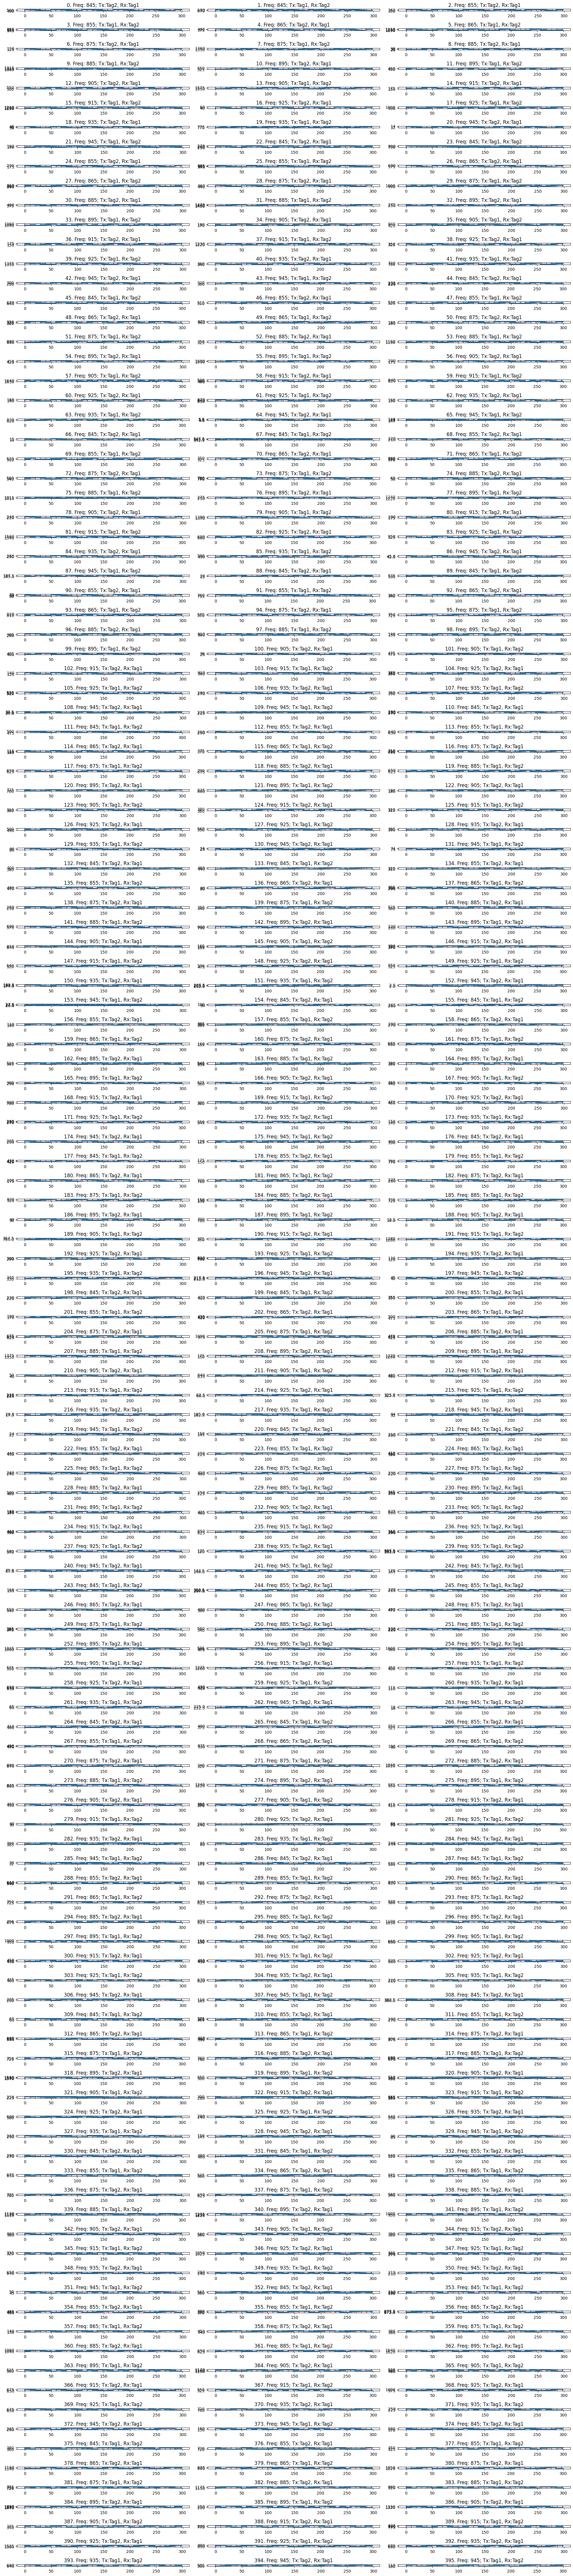

In [3]:
time_per_phase = 10/1000  # s
num_phases=6
default_MPPs=5
num_mpps=df_all.iloc[0]['NumMPPs']*default_MPPs
sampling_rate=1000
plotting=True
ver_lines = [0] + [ (time_per_phase-time_per_phase*0.01) * sampling_rate * (i + 1) for i in range(num_phases*num_mpps)]

processedDF=pd.DataFrame(columns=["Rx","Tx", "Voltages (mV)", "Phase1","Phase3","Phase4","Phase6","Phase7","Phase8",
                                "Frequency (MHz)", "Run Exp Num", "NumMPPs"])
processedDF_aggregated=pd.DataFrame(columns=["Rx","Tx","phase", "median", "std","freq", "dist", 'delta', "Experiment Number", "Unique Exp Number"])

if plotting:
    plt.figure(figsize=(20,90))

unique_exp_no=0
phase_order=[1,3,4,6,7,8]

for df_idx in range(len(df_all)):

    voltages=df_all.iloc[df_idx]['Voltages (mV)']
    phase_medians={
        1:[],
        3:[],
        4:[],
        6:[],
        7:[],
        8:[],
    }
    for idx,v in enumerate(ver_lines):
        if idx<len(ver_lines)-1:
            phase_medians[phase_order[int(idx%num_phases)]].append(np.median(voltages[int(ver_lines[idx]):int(ver_lines[idx+1])]))   
        if plotting:
            plt.subplot(len(df_all)//3+1, 3, df_idx+1)
            if idx%num_phases==0:
                plt.axvline(x=v, color='b', linestyle='-')
            else:
                plt.axvline(x=v, color='r', linestyle='--')
    
    for phase_out_idx in range(len(phase_medians[1])):
        entry={
            "Rx": df_all.iloc[df_idx]["Rx"],
            "Tx":df_all.iloc[df_idx]["Tx"],
            "Voltages (mV)":df_all.iloc[df_idx]["Voltages (mV)"],
            "Phase1":phase_medians[1][phase_out_idx],
            "Phase3":phase_medians[3][phase_out_idx],
            "Phase4":phase_medians[4][phase_out_idx],
            "Phase6":phase_medians[6][phase_out_idx],
            "Phase7":phase_medians[7][phase_out_idx],
            "Phase8":phase_medians[8][phase_out_idx],
            "Frequency (MHz)":df_all.iloc[df_idx]["Frequency (MHz)"],
            "Run Exp Num":df_all.iloc[df_idx]["Run Exp Num"],
            # "Tape Dist (m)":df_all.iloc[df_idx]["Tape dist"],
            # "Laser Dist (m)":df_all.iloc[df_idx]["Laser dist"],
            "Dist (m)":1.185,
            "NumMPPs":df_all.iloc[df_idx]["NumMPPs"],
        }
        processedDF=pd.concat([processedDF,pd.DataFrame([entry])],ignore_index=True)
        # print("Yo",phase_out_idx)
        # print(phase_medians)
        
    for phase in phase_order:
        entry_aggregated={
            "Rx":df_all.iloc[df_idx]["Rx"],
            "Tx":df_all.iloc[df_idx]["Tx"],
            "phase": str(phase),
            "median": np.mean(phase_medians[phase]), # mean of medians
            "std": np.std(phase_medians[phase]),
            "freq": df_all.iloc[df_idx]["Frequency (MHz)"]*1e6,
            "dist":1.185,
            'delta': max(phase_medians[phase])-min(phase_medians[phase]),
            "Experiment Number":df_all.iloc[df_idx]["Run Exp Num"],
            "Unique Exp Number":unique_exp_no,
            "allVoltages": phase_medians[phase]
        }
        processedDF_aggregated=pd.concat([processedDF_aggregated, pd.DataFrame([entry_aggregated])], ignore_index=True)
    unique_exp_no+=1
    
    # Identify and print bad MPPs
    # bad=False
    # for k in phase_medians.keys():
    #     assert(len(phase_medians[k])==num_mpps)
    #     if np.std(phase_medians[k])>1:
    #         d=1.185
    #         print(f"<== Bad data found at {df_idx} df_idx at phase {k} at T2T dist {d}.", end="\t")
    #         print(f"Num vals: {len(phase_medians[k])}, mean: {np.mean(phase_medians[k])}, stdev: {np.std(phase_medians[k])} ==>")
    
    if plotting:
        plt.plot(voltages,'.')
        plt.title(f'{df_idx}. Freq: {df_all.iloc[df_idx]["Frequency (MHz)"]}; Tx:{df_all.iloc[df_idx]["Tx"]}, Rx:{df_all.iloc[df_idx]["Rx"]}')
        plt.ylim([np.percentile(voltages, 1), np.percentile(voltages, 99)])
        plt.tight_layout()
    # break
if plotting:
    plt.savefig("MPPs.pdf")
    

    

In [4]:
with open("processedDF.pkl", 'wb') as f:
    pickle.dump(processedDF,f)
processedDF

,Rx,Tx,Voltages (mV),Phase1,Phase3,Phase4,Phase6,Phase7,Phase8,Frequency (MHz),Run Exp Num,NumMPPs,Dist (m)
0,Tag1,Tag2,"[163.84, 508.47, 506.26, 507.71, 507.86, 506.2...",507.320,504.120,499.120,491.795,490.040,506.675,845,0,1,1.185
1,Tag1,Tag2,"[163.84, 508.47, 506.26, 507.71, 507.86, 506.2...",507.135,503.700,498.630,491.915,489.470,506.520,845,0,1,1.185
2,Tag1,Tag2,"[163.84, 508.47, 506.26, 507.71, 507.86, 506.2...",506.600,503.205,498.205,491.795,489.130,506.825,845,0,1,1.185
3,Tag1,Tag2,"[163.84, 508.47, 506.26, 507.71, 507.86, 506.2...",506.750,502.325,498.020,491.760,488.935,506.255,845,0,1,1.185
4,Tag1,Tag2,"[163.84, 508.47, 506.26, 507.71, 507.86, 506.2...",506.295,503.355,497.595,491.680,489.280,506.180,845,0,1,1.185
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1975,Tag2,Tag1,"[642.37, 109.6, 109.06, 109.52, 109.22, 109.45...",109.450,112.690,99.680,99.450,102.960,108.220,945,17,1,1.185
1976,Tag2,Tag1,"[642.37, 109.6, 109.06, 109.52, 109.22, 109.45...",109.100,112.650,99.640,99.375,102.960,108.685,945,17,1,1.185
1977,Tag2,Tag1,"[642.37, 109.6, 109.06, 109.52, 109.22, 109.45...",109.330,112.805,99.830,99.150,102.845,108.530,945,17,1,1.185
1978,Tag2,Tag1,"[642.37, 109.6, 109.06, 109.52, 109.22, 109.45...",109.060,112.730,99.910,99.370,103.040,108.680,945,17,1,1.185


In [5]:
processedDF_aggregated

,Rx,Tx,phase,median,std,freq,dist,delta,Experiment Number,Unique Exp Number,allVoltages
0,Tag1,Tag2,1,506.820,0.368280,845000000.0,1.185,1.025,0,0,"[507.32, 507.135, 506.6, 506.75, 506.295]"
1,Tag1,Tag2,3,503.341,0.597774,845000000.0,1.185,1.795,0,0,"[504.12, 503.7, 503.20500000000004, 502.325, 5..."
2,Tag1,Tag2,4,498.314,0.522450,845000000.0,1.185,1.525,0,0,"[499.12, 498.63, 498.20500000000004, 498.02, 4..."
3,Tag1,Tag2,6,491.789,0.075723,845000000.0,1.185,0.235,0,0,"[491.79499999999996, 491.915, 491.795, 491.76,..."
4,Tag1,Tag2,7,489.371,0.377841,845000000.0,1.185,1.105,0,0,"[490.03999999999996, 489.47, 489.13, 488.93499..."
...,...,...,...,...,...,...,...,...,...,...,...
2371,Tag2,Tag1,3,112.781,0.134625,945000000.0,1.185,0.380,17,395,"[112.69, 112.65, 112.805, 112.73, 113.03]"
2372,Tag2,Tag1,4,99.771,0.098813,945000000.0,1.185,0.270,17,395,"[99.68, 99.64, 99.83, 99.91, 99.795]"
2373,Tag2,Tag1,6,99.428,0.209108,945000000.0,1.185,0.645,17,395,"[99.45, 99.375, 99.15, 99.37, 99.795]"
2374,Tag2,Tag1,7,103.015,0.141845,945000000.0,1.185,0.425,17,395,"[102.96000000000001, 102.96, 102.845, 103.04, ..."


In [6]:
# freq_range=np.array(range(775,1000,10))*1e6
# all_freqs, all_freqs_unwrapped, all_freqs_theoretical, all_freqs_theoretical_unwrapped, all_errors, \
#     selected_experiments_all = multidist_multifreq_phase_estimation(freq_range,processedDF_aggregated,correction_factor=0,plot=True)

# with open("no_correction_all_errs.pkl",'wb') as f:
#     pickle.dump(all_errors,f)
    
# with open("no_correction_all_phases.pkl",'wb') as f:
#     pickle.dump(all_freqs,f)

# with open("no_correction_all_phases_unwrapped.pkl",'wb') as f:
#     pickle.dump(all_freqs_unwrapped,f)    

# with open("theoretical_phase.pkl",'wb') as f:
#     pickle.dump(all_freqs_theoretical,f)    

### With offset correction using the ground truth.

In [7]:
# correction_offsets={}
# all_errors=None


# all_freqs, all_freqs_unwrapped, all_freqs_theoretical, all_freqs_theoretical_unwrapped, _,_=\
#     multidist_multifreq_phase_estimation(freq_range,processedDF_aggregated,correction_factor=0,plot=False)


# for freq in freq_range:
#     offset,best_error,errors=get_offset(all_freqs[freq],freq)
#     # print(f"Freq {freq//1e6};\t Mean:{np.mean(errors)};\t Median:{np.median(errors)};\t Std:{np.std(errors)}")
#     # if all_errors is None:
#     #     all_errors=errors
#     # else:
#     #     all_errors=np.concat((all_errors,errors))
#     correction_offsets[freq]=offset



# all_freqs, all_freqs_unwrapped, all_freqs_theoretical, all_freqs_theoretical_unwrapped, all_errors,_=\
#     multidist_multifreq_phase_estimation(freq_range,processedDF_aggregated,correction_factor=correction_offsets,plot=True)


# with open("gt_correction_all_errs.pkl",'wb') as f:
#     pickle.dump(all_errors,f)
    
# with open("gt_correction_all_phases.pkl",'wb') as f:
#     pickle.dump(all_freqs,f)

# with open("gt_correction_all_phases_unwrapped.pkl",'wb') as f:
#     pickle.dump(all_freqs_unwrapped,f)    

### With correction offsets from pretrained

In [8]:
# correction_offsets=pickle.load(open("/Users/manavjeet/git/T2TExperiments/DistExperiments/correction_offsets.pkl",'rb'))

# all_freqs, all_freqs_unwrapped, all_freqs_theoretical, all_freqs_theoretical_unwrapped, all_errors,_=\
#     multidist_multifreq_phase_estimation(freq_range,processedDF_aggregated,correction_factor=correction_offsets,plot=True)


# with open("pretrained_correction_all_errs.pkl",'wb') as f:
#     pickle.dump(all_errors,f)
    
# with open("pretrained_correction_all_phases.pkl",'wb') as f:
#     pickle.dump(all_freqs,f)

# with open("pretrained_correction_all_phases_unwrapped.pkl",'wb') as f:
#     pickle.dump(all_freqs_unwrapped,f)